# Transformer 기반 한국어 챗봇 프로젝트

* Transformer 아키텍처로 한국어 챗봇을 구현. 
* 데이터 정제, Pecab 토큰화, Lexical Substitution 데이터 증강, Transformer 모델 학습/평가

In [1]:
!pip install pecab gensim nltk matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.4/26.4 MB 117.8 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 146.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.0/802.0 kB 48.9 MB/s eta 0:00:00
  DEPRECATION: Building 'pecab' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pecab'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for pecab: filename=pecab-1.0.8-py3-none-any.whl size=26646750 sha256=a2a704e4746cf6cd269202326515f6e6a55d985624270fd5b6be4f3b61f1a13d
  Stored in directory: /home/j

In [2]:
import pandas as pd
import numpy as np
import os
import re
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from pecab import PeCab
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import pickle
import gensim
import math
import urllib.request

import matplotlib.font_manager as fm

plt.rc('font', family='URW Gothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
# if os.path.exists(font_path):
#     fm.fontManager.addfont(font_path)
#     plt.rc('font', family='NanumGothic')
#     plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

## 1. 데이터 다운로드 및 로드

In [3]:
DATA_PATH = 'data/ChatbotData.csv'
WV_PATH = 'data/ko.bin'
DATA_URL = 'https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv'
WV_URL = 'https://github.com/Kyubyong/wordvectors/raw/master/ko/ko.bin'

def load_data(path):
    # 파일이 없으면 다운로드 수행
    if not os.path.exists(path):
        print(f"{path} not found. Downloading from {DATA_URL}...")
        os.makedirs(os.path.dirname(path), exist_ok=True)
        urllib.request.urlretrieve(DATA_URL, path)
        print("Download completed.")
    
    df = pd.read_csv(path)
    questions = df['Q'].tolist()
    answers = df['A'].tolist()
    return questions, answers

## 2. 데이터 정제

In [4]:
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-zA-Z가-힣0-9!?,.]", " ", sentence)
    sentence = re.sub(r" {2,}", " ", sentence)
    sentence = sentence.strip()
    return sentence

## 3. 토큰화 및 데이터셋 구축 (Caching 포함)

In [5]:
CORPUS_PATH = 'data/corpus.pkl'

def build_corpus(questions, answers, max_len=40, corpus_path=CORPUS_PATH):
    # 캐시된 파일이 있으면 로드
    if os.path.exists(corpus_path):
        print(f"Loading corpus from {corpus_path}...")
        with open(corpus_path, 'rb') as f:
            que_corpus, ans_corpus = pickle.load(f)
        return que_corpus, ans_corpus

    print("Building new corpus...")
    pecab = PeCab()
    que_corpus, ans_corpus = [], []
    seen = set()
    
    for q, a in tqdm(zip(questions, answers), total=len(questions), desc="Building Corpus"):
        q = preprocess_sentence(q)
        a = preprocess_sentence(a)
        if (q, a) in seen: continue
        seen.add((q, a))
        
        q_tokens = pecab.morphs(q)
        a_tokens = pecab.morphs(a)
        
        if len(q_tokens) <= max_len and len(a_tokens) <= max_len:
            que_corpus.append(q_tokens)
            ans_corpus.append(a_tokens)
            
    # 로컬에 저장
    print(f"Saving corpus to {corpus_path}...")
    os.makedirs(os.path.dirname(corpus_path), exist_ok=True)
    with open(corpus_path, 'wb') as f:
        pickle.dump((que_corpus, ans_corpus), f)
        
    return que_corpus, ans_corpus

## 4. 데이터 증강 (Lexical Substitution)

In [6]:
def load_word2vec(path):
    # 파일이 없으면 다운로드 수행
    if not os.path.exists(path):
        print(f"{path} not found. Downloading from {WV_URL}...")
        os.makedirs(os.path.dirname(path), exist_ok=True)
        try:
            urllib.request.urlretrieve(WV_URL, path)
            print("Download completed.")
        except Exception as e:
            print(f"Failed to download Word2Vec: {e}")
            return None

    # Try multiple loading methods for older/binary ko.bin files
    try:
        # 1. Native gensim load
        model = gensim.models.Word2Vec.load(path)
        return model.wv
    except:
        try:
            # 2. KeyedVectors load
            return gensim.models.KeyedVectors.load(path)
        except:
            try:
                # 3. Direct pickle load with latin1 (for legacy models)
                with open(path, 'rb') as f:
                    data = pickle.load(f, encoding='latin1')
                
                if hasattr(data, 'syn0') and hasattr(data, 'index2word'):
                    from gensim.models.keyedvectors import KeyedVectors
                    kv = KeyedVectors(vector_size=data.vector_size if hasattr(data, 'vector_size') else data.syn0.shape[1])
                    kv.add_vectors(data.index2word, data.syn0)
                    return kv
                return None
            except Exception as e:
                try:
                    # 4. load_word2vec_format
                    return gensim.models.KeyedVectors.load_word2vec_format(path, binary=True)
                except Exception as e2:
                    print(f"Failed to load Word2Vec: {e2}")
                    return None

def lexical_sub(tokens, wv):
    if not tokens or wv is None: return tokens
    valid_tokens = [tok for tok in tokens if tok in wv]
    if not valid_tokens: return tokens
    
    selected_tok = random.choice(valid_tokens)
    similar_word = wv.most_similar(selected_tok)[0][0]
    return [similar_word if tok == selected_tok else tok for tok in tokens]

def augment_data(que_corpus, ans_corpus, wv):
    augmented_que, augmented_ans = [], []
    
    if wv is None:
        print("Word2Vec model not found. Skipping augmentation.")
        return que_corpus, ans_corpus

    for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus), desc="Augmenting"):
        augmented_que.append(q)
        augmented_ans.append(a)
        augmented_que.append(lexical_sub(q, wv))
        augmented_ans.append(a)
        augmented_que.append(q)
        augmented_ans.append(lexical_sub(a, wv))
    return augmented_que, augmented_ans

## 5. 데이터 벡터화

In [7]:
def tokenize_and_vectorize(que_corpus, ans_corpus):
    vocab = {"<pad>": 0, "<unk>": 1, "<start>": 2, "<end>": 3}
    for sentence in que_corpus + ans_corpus:
        for word in sentence:
            if word not in vocab: vocab[word] = len(vocab)
                
    def sentence_to_ids(sentence, vocab, is_target=False):
        ids = [vocab["<start>"]] if is_target else []
        ids.extend([vocab.get(word, vocab["<unk>"]) for word in sentence])
        if is_target: ids.append(vocab["<end>"])
        return ids

    que_vector = [sentence_to_ids(s, vocab) for s in que_corpus]
    ans_vector = [sentence_to_ids(s, vocab, is_target=True) for s in ans_corpus]
    return que_vector, ans_vector, vocab

def pad_sequences(sequences, max_len, pad_value=0):
    padded = np.full((len(sequences), max_len), pad_value)
    for i, seq in enumerate(sequences):
        length = min(len(seq), max_len)
        padded[i, :length] = seq[:length]
    return torch.tensor(padded, dtype=torch.long)

## 6. Transformer 모델 컴포넌트

In [8]:
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

def generate_padding_mask(seq):
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()

def generate_lookahead_mask(size):
    return torch.triu(torch.ones(size, size), diagonal=1)

def generate_masks(src, tgt, device):
    enc_mask = generate_padding_mask(src).to(device)
    dec_enc_mask = generate_padding_mask(src).to(device)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1]).unsqueeze(0).unsqueeze(1).to(device)
    dec_tgt_padding_mask = generate_padding_mask(tgt).to(device)
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)
    return enc_mask, dec_enc_mask, dec_mask

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads, self.d_model = num_heads, d_model
        self.depth = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))
        scaled_qk = QK / math.sqrt(d_k)
        if mask is not None: scaled_qk += (mask * -1e9)
        attentions = F.softmax(scaled_qk, dim=-1)
        return torch.matmul(attentions, V), attentions

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        return x.view(bsz, seq_len, self.num_heads, self.depth).permute(0, 2, 1, 3)

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        WQ, WK, WV = self.W_q(Q), self.W_k(K), self.W_v(V)
        out, attn = self.scaled_dot_product_attention(self.split_heads(WQ), self.split_heads(WK), self.split_heads(WV), mask)
        return self.linear(self.combine_heads(out)), attn

class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1, self.fc2 = nn.Linear(d_model, d_ff), nn.Linear(d_ff, d_model)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1, self.norm2 = nn.LayerNorm(d_model, eps=1e-6), nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)
    def forward(self, x, mask):
        res = x
        out, attn = self.mha(self.norm1(x), self.norm1(x), self.norm1(x), mask)
        out = self.do(out) + res
        res = out
        out = self.do(self.ffn(self.norm2(out))) + res
        return out, attn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm1, self.norm2, self.norm3 = nn.LayerNorm(d_model, eps=1e-6), nn.LayerNorm(d_model, eps=1e-6), nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)
    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        res = x
        out, attn1 = self.mha1(self.norm1(x), self.norm1(x), self.norm1(x), padding_mask)
        out = self.do(out) + res
        res = out
        out, attn2 = self.mha2(self.norm2(out), enc_out, enc_out, dec_enc_mask)
        out = self.do(out) + res
        res = out
        out = self.do(self.ffn(self.norm3(out))) + res
        return out, attn1, attn2

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
    def forward(self, x, mask):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            attns.append(attn)
        return x, attns

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        attns, enc_attns = [], []
        for layer in self.layers:
            x, attn, enc_attn = layer(x, enc_out, dec_enc_mask, padding_mask)
            attns.append(attn)
            enc_attns.append(enc_attn)
        return x, attns, enc_attns

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, pos_len, dropout=0.2):
        super().__init__()
        self.d_model = float(d_model)
        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        self.register_buffer("pos_encoding", torch.tensor(positional_encoding(pos_len, d_model), dtype=torch.float32))
        self.do = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)
    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x) * math.sqrt(self.d_model)
        out += self.pos_encoding[:seq_len, :].unsqueeze(0)
        return self.do(out)
    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_out, _ = self.encoder(self.embedding(self.enc_emb, enc_in), enc_mask)
        dec_out, _, _ = self.decoder(self.embedding(self.dec_emb, dec_in), enc_out, dec_enc_mask, dec_mask)
        return self.fc(dec_out)

## 7. 학습 및 평가 로직

In [9]:
def loss_function(real, pred):
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    mask = (real != 0).float()
    return (loss_.view(real.size()) * mask).sum() / mask.sum()

class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model, self.warmup_steps = d_model, warmup_steps
    def __call__(self, step):
        step = float(step + 1)
        return (self.d_model ** -0.5) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))

def calculate_bleu(reference, candidate):
    return sentence_bleu([reference], candidate, smoothing_function=SmoothingFunction().method1)

def evaluate_with_attention(sentence, transformer, vocab, rev_vocab, device, max_len=40):
    transformer.eval()
    sentence = preprocess_sentence(sentence)
    pecab = PeCab()
    tokens = pecab.morphs(sentence)
    
    enc_in = torch.tensor([[vocab.get(t, vocab["<unk>"]) for t in tokens]], dtype=torch.long).to(device)
    dec_in = torch.tensor([[vocab["<start>"]]], dtype=torch.long).to(device)
    
    attention_weights = None
    
    for _ in range(max_len):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_in, dec_in, device)
        predictions, enc_out, dec_enc_attns = transformer_with_attn(transformer, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask)
        prediction = predictions[:, -1:, :].argmax(dim=-1)
        
        if prediction.item() == vocab["<end>"]: break
        dec_in = torch.cat([dec_in, prediction], dim=-1)
        attention_weights = dec_enc_attns[-1]
        
    ids = dec_in.squeeze().tolist()[1:]
    response = [rev_vocab.get(i, "<unk>") for i in ids]
    return response, attention_weights, tokens

def transformer_with_attn(model, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
    enc_out, _ = model.encoder(model.embedding(model.enc_emb, enc_in), enc_mask)
    dec_out, dec_attns, dec_enc_attns = model.decoder(model.embedding(model.dec_emb, dec_in), enc_out, dec_enc_mask, dec_mask)
    logits = model.fc(dec_out)
    return logits, enc_out, dec_enc_attns

def visualize_attention(sentence, response, attention, tokens):
    if len(attention.shape) == 4:
        attention = attention.squeeze(0)
    attention = attention.mean(dim=0).cpu().detach().numpy()
    
    fig = plt.figure(figsize=(2, 2))
    ax = fig.add_subplot(1, 1, 1)
    cax = ax.matshow(attention, cmap='viridis')
    fig.colorbar(cax)
    
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(response)))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(response)
    
    # os.makedirs('results', exist_ok=True)
    # cleaned_sentence = re.sub(r'[^a-zA-Z가-힣0-9]', '_', sentence)[:20]
    # filename = f"results/attention_{cleaned_sentence}.png"
    # plt.savefig(filename)
    # print(f"Attention plot saved to {filename}")
    
    plt.show()

## 8. 전체 실행 과정

Using device: cuda
data/ChatbotData.csv not found. Downloading from https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv...
Download completed.
Building new corpus...


Building Corpus:  34%|███▍      | 4045/11823 [00:24<00:37, 207.14it/s]/opt/conda/lib/python3.12/site-packages/pecab/_tokenizer.py:265: RuntimeWarning: overflow encountered in scalar add
  from_pos_data.costs[idx]
Building Corpus:  76%|███████▋  | 9031/11823 [01:07<00:43, 63.88it/s]/opt/conda/lib/python3.12/site-packages/pecab/_tokenizer.py:274: RuntimeWarning: overflow encountered in scalar add
  least_cost += word_cost
Building Corpus: 100%|██████████| 11823/11823 [01:42<00:00, 114.90it/s]


Saving corpus to data/corpus.pkl...
data/ko.bin not found. Downloading from https://github.com/Kyubyong/wordvectors/raw/master/ko/ko.bin...
Failed to download Word2Vec: HTTP Error 404: Not Found
Word2Vec model not found. Skipping augmentation.
Total samples after augmentation: 11749


Epoch 1 [val]: 100%|██████████| 19/19 [00:01<00:00, 17.12it/s]


[Epoch 1] train_loss=63.3232 | val_loss=40.9390


...

[Epoch 8] train_loss=10.7639 | val_loss=10.8088


Epoch 9 [val]: 100%|██████████| 19/19 [00:01<00:00, 16.38it/s]


[Epoch 9] train_loss=9.0352 | val_loss=9.6860


Epoch 10 [val]: 100%|██████████| 19/19 [00:01<00:00, 16.49it/s]


[Epoch 10] train_loss=7.6239 | val_loss=9.2113

 Val loss 바닥(V의 최저점) epoch = 10
   train_loss=7.6239, val_loss=9.2113


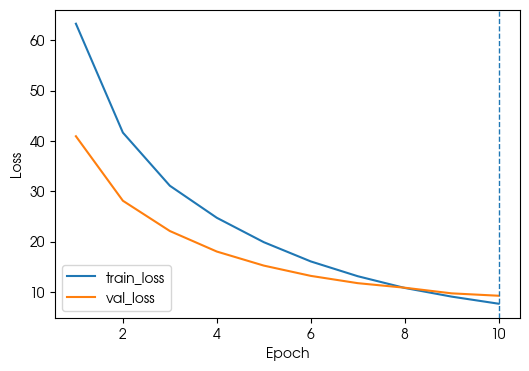

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

questions, answers = load_data(DATA_PATH)
que_corpus, ans_corpus = build_corpus(questions, answers)

wv = load_word2vec(WV_PATH)
aug_que, aug_ans = augment_data(que_corpus, ans_corpus, wv)
print(f"Total samples after augmentation: {len(aug_que)}")

que_vector, ans_vector, vocab = tokenize_and_vectorize(aug_que, aug_ans)
rev_vocab = {v: k for k, v in vocab.items()}
MAX_LEN = 40
BATCH_SIZE=64
enc_train = pad_sequences(que_vector, MAX_LEN)
dec_train = pad_sequences(ans_vector, MAX_LEN)

from torch.utils.data import TensorDataset, DataLoader, random_split
dataset = TensorDataset(enc_train, dec_train)
# ====== train/val split ======
val_ratio = 0.1
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# !!! D_MODEL = 368
D_MODEL = 512
N_HEADS = 8
D_FF=1024
DROPOUT=0.2
N_LAYERS=6

transformer = Transformer(n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
                          src_vocab_size=len(vocab), tgt_vocab_size=len(vocab), pos_len=MAX_LEN, dropout=DROPOUT).to(device)
optimizer = torch.optim.Adam(transformer.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
lr_scheduler = LearningRateScheduler(D_MODEL)

train_losses = []
val_losses = []

EPOCHS = 10
total_step = 0

for epoch in range(EPOCHS):
    # ====== Train ======
    transformer.train()
    total_train_loss = 0.0

    for b_enc, b_dec in tqdm(train_loader, desc=f"Epoch {epoch+1} [train]"):
        b_enc, b_dec = b_enc.to(device), b_dec.to(device)
        dec_input, dec_real = b_dec[:, :-1], b_dec[:, 1:]

        enc_mask, dec_enc_mask, dec_mask = generate_masks(b_enc, dec_input, device)

        optimizer.param_groups[0]['lr'] = lr_scheduler(total_step)
        optimizer.zero_grad()

        pred = transformer(b_enc, dec_input, enc_mask, dec_enc_mask, dec_mask)
        loss = loss_function(dec_real, pred)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        total_step += 1

    avg_train = total_train_loss / len(train_loader)
    train_losses.append(avg_train)

    # ====== Validation ======
    transformer.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for b_enc, b_dec in tqdm(val_loader, desc=f"Epoch {epoch+1} [val]"):
            b_enc, b_dec = b_enc.to(device), b_dec.to(device)
            dec_input, dec_real = b_dec[:, :-1], b_dec[:, 1:]

            enc_mask, dec_enc_mask, dec_mask = generate_masks(b_enc, dec_input, device)

            pred = transformer(b_enc, dec_input, enc_mask, dec_enc_mask, dec_mask)
            vloss = loss_function(dec_real, pred)

            total_val_loss += vloss.item()

    avg_val = total_val_loss / len(val_loader)
    val_losses.append(avg_val)

    print(f"[Epoch {epoch+1}] train_loss={avg_train:.4f} | val_loss={avg_val:.4f}")

# ====== V자 바닥(최소 val loss) epoch 찾기 ======
best_epoch = int(np.argmin(val_losses)) + 1  # epoch는 1부터 보이게
print(f"\n Val loss 바닥(V의 최저점) epoch = {best_epoch}")
print(f"   train_loss={train_losses[best_epoch-1]:.4f}, val_loss={val_losses[best_epoch-1]:.4f}")

# ====== 러닝커브 그리기 ======
plt.figure(figsize=(6,4))
plt.plot(range(1, EPOCHS+1), train_losses, label="train_loss")
plt.plot(range(1, EPOCHS+1), val_losses, label="val_loss")
plt.axvline(best_epoch, linestyle="--", linewidth=1)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [11]:
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

In [12]:
import warnings
warnings.filterwarnings(action='ignore') # 모든 경고 무시

test_responses = []

for ts in test_sentences:
    response, attention, tokens = evaluate_with_attention(ts, transformer, vocab, rev_vocab, device)
    test_responses.append(' '.join(response))
    
print("\n# 예문")
for i, s in enumerate(test_sentences):
    print(f"{i}. {s}")

print("\n# 제출")
for i, s in enumerate(test_responses):
    print(f"> {i}. {s}")

print("\n# Hyperparameters")
print(f"n_layers: {N_LAYERS}")
print(f"d_model: {D_MODEL}")
print(f"n_heads: {N_HEADS}")
print(f"d_ff: {D_FF}")
print(f"dropout: {DROPOUT}")

print("\n# Training Parameters")
# print(f"Warmup Steps: {}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epoch At: {EPOCHS}")



# 예문
0. 지루하다, 놀러가고 싶어.
1. 오늘 일찍 일어났더니 피곤하다.
2. 간만에 여자친구랑 데이트 하기로 했어.
3. 집에 있는다는 소리야.

# 제출
> 0. 잘 해 주 세요 .
> 1. 잘 할 거 예요 .
> 2. 사랑 은 정말 사랑 하 는 게 만들 어 보 는 게 만들 어 보 세요 .
> 3. 잘 생각 해 보 세요 .

# Hyperparameters
n_layers: 6
d_model: 512
n_heads: 8
d_ff: 1024
dropout: 0.2

# Training Parameters
Batch Size: 64
Epoch At: 10


## 9. 결론

* 학습 결과 train loss는 63 → 7.6, validation loss는 40 → 9.2로 감소하였다.
* Validation loss가 마지막 epoch까지 감소하는 것으로 보아 과적합은 발생하지 않았다.
* Transformer 기반 챗봇이 기본적인 응답 생성 능력을 학습한 것을 확인할 수 있었다.